### LightGBM

In [1]:
import h5py
import numpy as np
import lightgbm as lgb
import time
import matplotlib.pyplot as plt  

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample
from sklearn.model_selection import RandomizedSearchCV


# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0, 1, 2, 3, 5]

train_mask = np.isin(y_train, valid_labels)
test_mask = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test = X_test[test_mask]
y_test = y_test[test_mask]


# ==========================================================
# 3. MAP TO BINARY: Sleep=0, Wake=1
# ==========================================================

sleep_stages = [1, 2, 3, 5]

y_train_bin = np.copy(y_train)
y_test_bin = np.copy(y_test)

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1


# ==========================================================
# 4. UPSAMPLE WAKE (IF NEEDED)
# ==========================================================

X_sleep = X_train[y_train_bin == 0]
y_sleep = y_train_bin[y_train_bin == 0]

X_wake = X_train[y_train_bin == 1]
y_wake = y_train_bin[y_train_bin == 1]

if len(X_sleep) > len(X_wake):
    X_wake_up, y_wake_up = resample(
        X_wake, y_wake,
        replace=True,
        n_samples=len(X_sleep),
        random_state=42
    )
    X_train_bal = np.vstack([X_sleep, X_wake_up])
    y_train_bal = np.hstack([y_sleep, y_wake_up])
else:
    X_train_bal = X_train
    y_train_bal = y_train_bin

print(f"Balanced train size: {X_train_bal.shape}")

# ==========================================================
# 5. FEATURE GROUPING (MODALITIES)
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3", "C4", "A1", "A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG", "Pleth", "Pulse", "SpO2", "Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features
PSG_like = EEG_features + EOG_features + EMG_features
wearable = cardiac + acc

all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)

#Orange = the printed name, white = defined name
feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG, # PSG-like
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc+ Car": acc + cardiac, #wearable
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
    #"Accelerometer + EEG": acc + EEG_features
    #"Wearable": wearable,
}

feature_to_idx = {f: i for i, f in enumerate(feature_names)}

# ==========================================================
# 6. LIGHTGBM PARAMETERS
# ==========================================================

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 70,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'class_weight': 'balanced',
    'n_jobs': -1,
    #'min_child_samples': 30,#ny
    #'max_depth': 30,#ny
    'random_state': 42
}

# ==========================================================
# 7. MODALITY COMPARISON LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        print("⚠ No features found. Skipping.")
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train_bal[:, idx]
    X_test_fs = X_test[:, idx]

    # Scale
    scaler = StandardScaler()
    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs = scaler.transform(X_test_fs)

    model = lgb.LGBMClassifier(**params)

    start = time.time()
    model.fit(X_train_fs, y_train_bal)
   
    start = time.time()


    print(f"Training time: {time.time() - start:.2f} sec")

    #--------------------------------------------------
    y_pred = model.predict(X_test_fs)
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_test_bin, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Wake is positive class (1)
    sensitivity = tp / (tp + fn)        # Recall Wake
    specificity = tn / (tn + fp)        # True Sleep rate

    acc_score = accuracy_score(y_test_bin, y_pred)

    #f1 = f1_score(y_test_bin, y_pred)
    f1_macro = f1_score(y_test_bin, y_pred, average='macro')   #Averages Sleep and Wake equally — better for imbalanced data.

    kappa = cohen_kappa_score(y_test_bin, y_pred)

    print(classification_report(y_test_bin, y_pred, target_names=["Sleep", "Wake"]))

    results[name] = {
    "Accuracy": acc_score,
    "F1": f1_macro,
    "Kappa": kappa,
    "Sensitivity": sensitivity,
    "Specifity": specificity,
        }


# ==========================================================
# 8. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k, v in results.items():
    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']:8.3f} | "
          f"{v['Specifity']:8.3f}")

print("--------------------------------------------------------------------------------")

# EEG is the strongest single modality
# Adding EOG to EEG gives a slight boost
# Adding EMG to EEG+EOG (PSG-like) doesen'test_mask
# Cardiac is good
# Accelerometer performs the worst, but it's expected
# Wearable (cardiac + acc) is better. This is seen in smart watches like Fitbit
# All features gives best performance, but it's not a huge jump from EEG+EOG or PSG-like. This suggests that the extra features add some value, but the core signal is in the EEG and EOG.

Train shape: (46398, 129)
Test shape: (11600, 129)
Balanced train size: (77662, 129)

Training with modality: EEG
Number of features: 60
[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15300
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training time: 0.00 sec
              precision    recall  f1-score   support

       Sleep       0.98      0.95      0.97      9708
        Wake       0.79      0.92      0.85      1872

    accuracy                           0.95     11580
   macro avg       0.89      0.94      0.91     11580
weighted avg       0.95      0.95      0.95     11580


Training with modality: EEG + EOG
Number of features: 84


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21420
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training time: 0.00 sec
              precision    recall  f1-score   support

       Sleep       0.98      0.96      0.97      9708
        Wake       0.82      0.92      0.87      1872

    accuracy                           0.95     11580
   macro avg       0.90      0.94      0.92     11580
weighted avg       0.96      0.95      0.95     11580


Training with modality: EEG + EOG + EMG
Number of features: 87


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22185
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training time: 0.00 sec
              precision    recall  f1-score   support

       Sleep       0.98      0.96      0.97      9708
        Wake       0.81      0.92      0.86      1872

    accuracy                           0.95     11580
   macro avg       0.90      0.94      0.92     11580
weighted avg       0.96      0.95      0.95     11580


Training with modality: Cardiac
Number of features: 16
[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing 

...

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26265
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training time: 0.00 sec
              precision    recall  f1-score   support

       Sleep       0.98      0.96      0.97      9708
        Wake       0.82      0.92      0.87      1872

    accuracy                           0.95     11580
   macro avg       0.90      0.94      0.92     11580
weighted avg       0.96      0.95      0.95     11580


Training with modality: All
Number of features: 121


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021841 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30684
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 121
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training time: 0.00 sec
              precision    recall  f1-score   support

       Sleep       0.99      0.97      0.98      9708
        Wake       0.84      0.93      0.88      1872

    accuracy                           0.96     11580
   macro avg       0.91      0.95      0.93     11580
weighted avg       0.96      0.96      0.96     11580



====================== FINAL MODALITY COMPARISON ========================
------------------------------------------------------------------------------
Modality             |    Acc | F1-macro |  Kappa |  

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



##### Feature selection test

In [9]:
import h5py
import numpy as np
import lightgbm as lgb
import time
import matplotlib.pyplot as plt  

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample
from sklearn.model_selection import RandomizedSearchCV


# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0, 1, 2, 3, 5]

train_mask = np.isin(y_train, valid_labels)
test_mask = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test = X_test[test_mask]
y_test = y_test[test_mask]


# ==========================================================
# 3. MAP TO BINARY: Sleep=0, Wake=1
# ==========================================================

sleep_stages = [1, 2, 3, 5]

y_train_bin = np.copy(y_train)
y_test_bin = np.copy(y_test)

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1


# ==========================================================
# 4. UPSAMPLE WAKE (IF NEEDED)
# ==========================================================

X_sleep = X_train[y_train_bin == 0]
y_sleep = y_train_bin[y_train_bin == 0]

X_wake = X_train[y_train_bin == 1]
y_wake = y_train_bin[y_train_bin == 1]

if len(X_sleep) > len(X_wake):
    X_wake_up, y_wake_up = resample(
        X_wake, y_wake,
        replace=True,
        n_samples=len(X_sleep),
        random_state=42
    )
    X_train_bal = np.vstack([X_sleep, X_wake_up])
    y_train_bal = np.hstack([y_sleep, y_wake_up])
else:
    X_train_bal = X_train
    y_train_bal = y_train_bin

print(f"Balanced train size: {X_train_bal.shape}")

# ==========================================================
# 5. FEATURE GROUPING (MODALITIES)
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3", "C4", "A1", "A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG", "Pleth", "Pulse", "SpO2", "Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features
PSG_like = EEG_features + EOG_features + EMG_features
wearable = cardiac + acc

all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)

#Orange = the printed name, white = defined name
feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG, # PSG-like
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc+ Car": acc + cardiac, #wearable
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
    #"Accelerometer + EEG": acc + EEG_features
    #"Wearable": wearable,
}

feature_to_idx = {f: i for i, f in enumerate(feature_names)}

# ==========================================================
# 6. LIGHTGBM PARAMETERS
# ==========================================================

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 70,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'class_weight': 'balanced',
    'n_jobs': -1,
    #'min_child_samples': 30,#ny
    #'max_depth': 30,#ny
    'random_state': 42
}

# ==========================================================
# 7. MODALITY COMPARISON LOOP (WITH FEATURE SELECTION)
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features BEFORE selection: {len(fs)}")

    if len(fs) == 0:
        print("⚠ No features found. Skipping.")
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train_bal[:, idx]
    X_test_fs = X_test[:, idx]

    # ======================================================
    # FEATURE SELECTION (ONLY ON TRAIN DATA) Get better results without feature selection, but it can be useful for interpretability and to speed up training.
    # ======================================================
    # k = min(80, X_train_fs.shape[1])  # safe cap
    # from sklearn.feature_selection import SelectKBest, f_classif

    # selector = SelectKBest(score_func=f_classif, k=k)
    # X_train_fs = selector.fit_transform(X_train_fs, y_train_bal)
    # X_test_fs = selector.transform(X_test_fs)

    # print(f"Number of features AFTER selection: {X_train_fs.shape[1]}")

    # ======================================================
    # SCALING
    # ======================================================
    scaler = StandardScaler()
    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs = scaler.transform(X_test_fs)

    # ======================================================
    # MODEL
    # ======================================================
    model = lgb.LGBMClassifier(**params)

    start = time.time()
    model.fit(X_train_fs, y_train_bal)

#     selected_indices = selector.get_support(indices=True)
#     selected_feature_names = [fs[i] for i in selected_indices]
    
#     importances = model.feature_importances_
#     feature_importance_pairs = list(zip(selected_feature_names, importances))

# # Sort descending
#     feature_importance_pairs = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)

#     print("\nTop 15 most important features:")
#     for feat, imp in feature_importance_pairs[:15]:
#         print(f"{feat}: {imp}")

#         print(f"Training time: {time.time() - start:.2f} sec")

    # ======================================================
    # EVALUATION
    # ======================================================
    y_pred = model.predict(X_test_fs)

    cm = confusion_matrix(y_test_bin, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    acc_score = accuracy_score(y_test_bin, y_pred)
    f1_macro = f1_score(y_test_bin, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test_bin, y_pred)

    print(classification_report(y_test_bin, y_pred, target_names=["Sleep", "Wake"]))

    results[name] = {
        "Accuracy": acc_score,
        "F1": f1_macro,
        "Kappa": kappa,
        "Sensitivity": sensitivity,
        "Specifity": specificity,
    }


# 8. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k, v in results.items():
    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']:8.3f} | "
          f"{v['Specifity']:8.3f}")

print("--------------------------------------------------------------------------------")


Train shape: (46398, 129)
Test shape: (11600, 129)
Balanced train size: (77662, 129)

Training with modality: EEG
Number of features BEFORE selection: 60
[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007662 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15300
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

       Sleep       0.98      0.95      0.97      9708
        Wake       0.79      0.92      0.85      1872

    accuracy                           0.95     11580
   macro avg       0.89      0.94      0.91     11580
weighted avg       0.95      0.95      0.95     11580


Training with modality: EEG + EOG
Number of features BEFORE selection: 84
[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21420
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

       Sleep       0.98      0.96      0.97      9708
        Wake       0.82      0.92      0.87      1872

    accuracy                           0.95     11580
   macro avg       0.90      0.94      0.92     11580
weighted avg       0.96      0.95      0.95     11580


Training with modality: EEG + EOG + EMG
Number of features BEFORE selection: 87
[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22185
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

       Sleep       0.98      0.94      0.96      9708
        Wake       0.73      0.90      0.81      1872

    accuracy                           0.93     11580
   macro avg       0.86      0.92      0.88     11580
weighted avg       0.94      0.93      0.93     11580


Training with modality: All PSG features
Number of features BEFORE selection: 103
[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26265
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

       Sleep       0.98      0.96      0.97      9708
        Wake       0.82      0.92      0.87      1872

    accuracy                           0.95     11580
   macro avg       0.90      0.94      0.92     11580
weighted avg       0.96      0.95      0.95     11580


Training with modality: All
Number of features BEFORE selection: 121
[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017672 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30684
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 121
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

       Sleep       0.99      0.97      0.98      9708
        Wake       0.84      0.93      0.88      1872

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


##### Adding standard deviation for the plot

Train shape: (46398, 129)
Test shape: (11600, 129)

Training: EEG
[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15300
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015567 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15300
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15300
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30684
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 121
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 38831, number of negative: 38831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30684
[LightGBM] [Info] Number of data points in the train set: 77662, number of used features: 121
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\anita\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


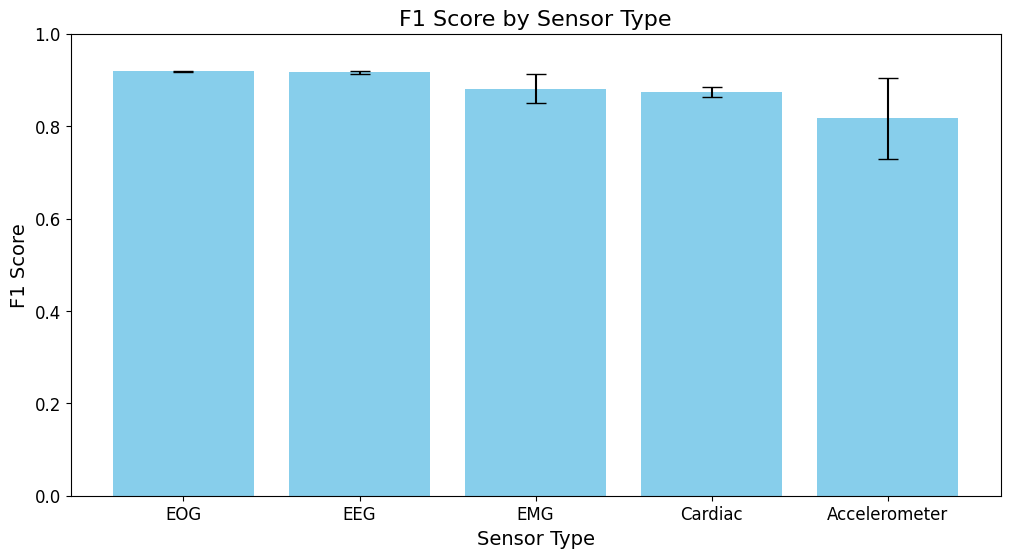

[np.float64(0.004050758239624429), np.float64(0.005079507435766741), np.float64(0.00430573780892453), np.float64(0.004547365871189302), np.float64(0.004156624349694389), np.float64(0.004404244496679639), np.float64(0.0062014744341477865), np.float64(0.005371519659676748), np.float64(0.0018329495379229121), np.float64(0.0029826502745919246)]


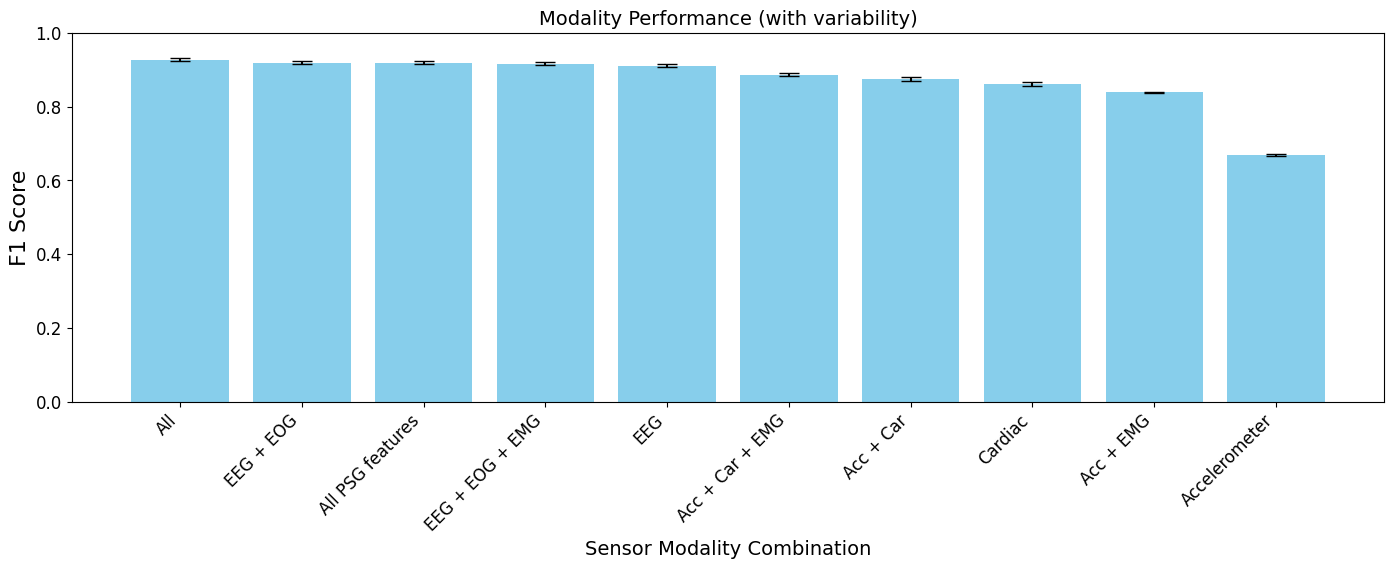

In [17]:
import h5py 
import numpy as np
import lightgbm as lgb
import time
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample

# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0, 1, 2, 3, 5]

train_mask = np.isin(y_train, valid_labels)
test_mask = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test = X_test[test_mask]
y_test = y_test[test_mask]

# ==========================================================
# 3. MAP TO BINARY
# ==========================================================

sleep_stages = [1, 2, 3, 5]

y_train_bin = np.copy(y_train)
y_test_bin = np.copy(y_test)

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1

# ==========================================================
# 4. UPSAMPLE WAKE
# ==========================================================

X_sleep = X_train[y_train_bin == 0]
y_sleep = y_train_bin[y_train_bin == 0]

X_wake = X_train[y_train_bin == 1]
y_wake = y_train_bin[y_train_bin == 1]

if len(X_sleep) > len(X_wake):
    X_wake_up, y_wake_up = resample(
        X_wake, y_wake,
        replace=True,
        n_samples=len(X_sleep),
        random_state=42
    )
    X_train_bal = np.vstack([X_sleep, X_wake_up])
    y_train_bal = np.hstack([y_sleep, y_wake_up])
else:
    X_train_bal = X_train
    y_train_bal = y_train_bin

# ==========================================================
# 5. FEATURE GROUPS
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3", "C4", "A1", "A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG", "Pleth", "Pulse", "SpO2", "Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_features + EOG_features,
    "EEG + EOG + EMG": EEG_features + EOG_features + EMG_features,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": EEG_features + EOG_features + EMG_features + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f: i for i, f in enumerate(feature_names)}

# ==========================================================
# 6. MODEL PARAMETERS
# ==========================================================

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'num_leaves': 70,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'class_weight': 'balanced',
    'n_jobs': -1
}

# ==========================================================
# 7. TRAINING WITH MULTIPLE RUNS
# ==========================================================

n_runs = 5
results = {}

for name, fs in feature_sets.items():

    print(f"\nTraining: {name}")

    if len(fs) == 0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train_bal[:, idx]
    X_test_fs = X_test[:, idx]

    scaler = StandardScaler()
    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs = scaler.transform(X_test_fs)

    f1_list = []

    for run in range(n_runs):
        model = lgb.LGBMClassifier(**params, random_state=run)
        model.fit(X_train_fs, y_train_bal)

          # NEW: Bootstrap the test set to see real performance variance
        X_res, y_res = resample(X_test_fs, y_test_bin, replace=True, random_state=run)
        y_pred = model.predict(X_res)
        
        f1 = f1_score(y_res, y_pred, average='macro')
        #y_pred = model.predict(X_test_fs)
        #f1 = f1_score(y_test_bin, y_pred, average='macro')
        f1_list.append(f1)

    results[name] = {
        "F1_mean": np.mean(f1_list),
        "F1_std": np.std(f1_list)
    }

# ==========================================================
# SENSOR CONTRIBUTION
# ==========================================================

sensor_scores = {
    "EEG": [], "EOG": [], "EMG": [], "Cardiac": [], "Accelerometer": []
}

for modality, data in results.items():
    f1 = data["F1_mean"]

    if "EEG" in modality: sensor_scores["EEG"].append(f1)
    if "EOG" in modality: sensor_scores["EOG"].append(f1)
    if "EMG" in modality: sensor_scores["EMG"].append(f1)
    if "Car" in modality or "Cardiac" in modality: sensor_scores["Cardiac"].append(f1)
    if "Acc" in modality or "Accelerometer" in modality: sensor_scores["Accelerometer"].append(f1)

avg_scores = {k: np.mean(v) if v else 0 for k, v in sensor_scores.items()}
std_scores = {k: np.std(v) if v else 0 for k, v in sensor_scores.items()}

# ==========================================================
# PLOT 1 (WITH WHISKERS)
# ==========================================================

labels = list(avg_scores.keys())
values = list(avg_scores.values())
errors = list(std_scores.values())

sorted_idx = np.argsort(values)[::-1]

labels = [labels[i] for i in sorted_idx]
values = [values[i] for i in sorted_idx]
errors = [errors[i] for i in sorted_idx]

plt.figure(figsize=(12,6))
plt.bar(labels, values, yerr=errors, capsize=7, color='skyblue')

plt.title("F1 Score by Sensor Type", fontsize=16)
plt.ylabel("F1 Score", fontsize=14)
plt.xlabel("Sensor Type", fontsize=14)

# for i, v in enumerate(values):
#     plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

#Increase label sizes (not x and y label, but bar label)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0,1)
plt.show()

# ==========================================================
# PLOT 2 (MODALITIES WITH WHISKERS)
# ==========================================================

modalities = list(results.keys())
means = [v["F1_mean"] for v in results.values()]
stds = [v["F1_std"] for v in results.values()]


sorted_idx = np.argsort(means)[::-1]

modalities = [modalities[i] for i in sorted_idx]
means = [means[i] for i in sorted_idx]
stds = [stds[i] for i in sorted_idx]

plt.figure(figsize=(14,6))
plt.bar(modalities, means, yerr=stds, capsize=7, color='skyblue')

plt.xticks(rotation=45, ha='right', fontsize=14)
plt.ylabel("F1 Score", fontsize=16)
plt.ylim(0,1)
plt.title("Modality Performance (with variability)", fontsize=14)
plt.xlabel("Sensor Modality Combination", fontsize=14)

# Show value on top of bars
# for i, v in enumerate(means):
#     plt.text(i, v + 0.015, f"{v:.2f}", ha='center')

print(stds)
plt.tight_layout()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


### RF

In [3]:
import h5py
import numpy as np
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample

# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0, 1, 2, 3, 5]

train_mask = np.isin(y_train, valid_labels)
test_mask = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test = X_test[test_mask]
y_test = y_test[test_mask]

# ==========================================================
# 3. MAP TO BINARY: Sleep=0, Wake=1
# ==========================================================

sleep_stages = [1, 2, 3, 5]

y_train_bin = np.copy(y_train)
y_test_bin = np.copy(y_test)

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1

# ==========================================================
# 4. FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3", "C4", "A1", "A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG", "Pleth", "Pulse", "SpO2", "Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features
all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)

feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
}

feature_to_idx = {f: i for i, f in enumerate(feature_names)}

# ==========================================================
# 5. RANDOM FOREST PARAMETERS
# ==========================================================

rf_params = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
}

# ==========================================================
# 6. MODALITY LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_tr = X_train[:, idx]
    X_te = X_test[:, idx]

    # -------------------------
    # UPSAMPLE TRAIN ONLY
    # -------------------------
    X_sleep = X_tr[y_train_bin == 0]
    y_sleep = y_train_bin[y_train_bin == 0]

    X_wake = X_tr[y_train_bin == 1]
    y_wake = y_train_bin[y_train_bin == 1]

    if len(X_sleep) > len(X_wake):
        X_wake_up, y_wake_up = resample(
            X_wake, y_wake,
            replace=True,
            n_samples=len(X_sleep),
            random_state=42
        )
        X_tr_bal = np.vstack([X_sleep, X_wake_up])
        y_tr_bal = np.hstack([y_sleep, y_wake_up])
    else:
        X_tr_bal = X_tr
        y_tr_bal = y_train_bin

    # -------------------------
    # TRAIN
    # -------------------------
    start = time.time()
    model = RandomForestClassifier(**rf_params)
    model.fit(X_tr_bal, y_tr_bal)
    print(f"Training time: {time.time() - start:.2f} sec")

    # -------------------------
    # EVALUATE ON TEST SET
    # -------------------------
    y_pred = model.predict(X_te)

    cm = confusion_matrix(y_test_bin, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    results[name] = {
        "Accuracy": accuracy_score(y_test_bin, y_pred),
        "F1": f1_score(y_test_bin, y_pred, average="macro"),
        "Kappa": cohen_kappa_score(y_test_bin, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }

    print(classification_report(y_test_bin, y_pred, target_names=["Sleep", "Wake"]))

# ==========================================================
# 7. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k, v in results.items():
    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']:8.3f} | "
          f"{v['Specificity']:8.3f}")

print("--------------------------------------------------------------------------------")

Train shape: (46398, 129)
Test shape: (11600, 129)

Training with modality: EEG
Number of features: 60
Training time: 32.74 sec
              precision    recall  f1-score   support

       Sleep       0.97      0.97      0.97      9708
        Wake       0.83      0.85      0.84      1872

    accuracy                           0.95     11580
   macro avg       0.90      0.91      0.90     11580
weighted avg       0.95      0.95      0.95     11580


Training with modality: EEG + EOG
Number of features: 84
Training time: 41.67 sec
              precision    recall  f1-score   support

       Sleep       0.97      0.97      0.97      9708
        Wake       0.84      0.85      0.85      1872

    accuracy                           0.95     11580
   macro avg       0.90      0.91      0.91     11580
weighted avg       0.95      0.95      0.95     11580


Training with modality: EEG + EOG + EMG
Number of features: 87
Training time: 39.68 sec
              precision    recall  f1-score   

##### K fold test

In [ ]:
import h5py
import numpy as np
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold

# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

# ==========================================================
# 3. MAP TO BINARY: Sleep=0, Wake=1
# ==========================================================

sleep_stages = [1,2,3,5]

y_train_bin = np.copy(y_train)
y_test_bin = np.copy(y_test)

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1

# ==========================================================
# 4. FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features

all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)

feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc+ Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}

# ==========================================================
# 5. RANDOM FOREST PARAMETERS
# ==========================================================

rf_params = {
    "n_estimators":300,
    "max_depth":None,
    "min_samples_split":2,
    "min_samples_leaf":1,
    "max_features":"sqrt",
    "class_weight":"balanced",
    "random_state":42,
    "n_jobs":-1
}

# ==========================================================
# 6. CROSS-VALIDATION SETUP
# ==========================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================================
# 7. MODALITY LOOP WITH CV
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    f1_scores = []
    acc_scores = []
    kappa_scores = []
    sens_scores = []
    spec_scores = []

    start_total = time.time()

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train[:, idx], y_train_bin)):

        X_tr = X_train[:, idx][train_idx]
        X_val = X_train[:, idx][val_idx]
        y_tr = y_train_bin[train_idx]
        y_val = y_train_bin[val_idx]

        # -------------------------
        # UPSAMPLE TRAIN ONLY
        # -------------------------
        X_sleep = X_tr[y_tr == 0]
        y_sleep = y_tr[y_tr == 0]

        X_wake = X_tr[y_tr == 1]
        y_wake = y_tr[y_tr == 1]

        if len(X_sleep) > len(X_wake):
            X_wake_up, y_wake_up = resample(
                X_wake, y_wake,
                replace=True,
                n_samples=len(X_sleep),
                random_state=42
            )
            X_tr_bal = np.vstack([X_sleep, X_wake_up])
            y_tr_bal = np.hstack([y_sleep, y_wake_up])
        else:
            X_tr_bal = X_tr
            y_tr_bal = y_tr

        # -------------------------
        # TRAIN
        # -------------------------
        model = RandomForestClassifier(**rf_params)
        model.fit(X_tr_bal, y_tr_bal)

        # -------------------------
        # EVALUATE
        # -------------------------
        y_pred = model.predict(X_val)

        cm = confusion_matrix(y_val, y_pred)
        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)

        f1 = f1_score(y_val, y_pred, average="macro")
        acc = accuracy_score(y_val, y_pred)
        kappa = cohen_kappa_score(y_val, y_pred)

        f1_scores.append(f1)
        acc_scores.append(acc)
        kappa_scores.append(kappa)
        sens_scores.append(sensitivity)
        spec_scores.append(specificity)

        print(f"Fold {fold+1} F1: {f1:.3f}")

    print(f"Total CV time: {time.time()-start_total:.2f} sec")

    results[name] = {
        "Accuracy": np.mean(acc_scores),
        "F1": np.mean(f1_scores),
        "Kappa": np.mean(kappa_scores),
        "Sensitivity": np.mean(sens_scores),
        "Specificity": np.mean(spec_scores)
    }

# ==========================================================
# 8. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']:8.3f} | "
          f"{v['Specificity']:8.3f}")

print("--------------------------------------------------------------------------------")

Train shape: (46398, 129)
Test shape: (11600, 129)

Training with modality: EEG
Number of features: 60
Fold 1 F1: 0.909
Fold 2 F1: 0.897
Fold 3 F1: 0.897
Fold 4 F1: 0.900
Fold 5 F1: 0.905
Total CV time: 102.85 sec

Training with modality: EEG + EOG
Number of features: 84
Fold 1 F1: 0.913
Fold 2 F1: 0.902
Fold 3 F1: 0.904
Fold 4 F1: 0.907
Fold 5 F1: 0.906
Total CV time: 134.32 sec

Training with modality: EEG + EOG + EMG
Number of features: 87
Fold 1 F1: 0.911
Fold 2 F1: 0.905
Fold 3 F1: 0.904
Fold 4 F1: 0.905
Fold 5 F1: 0.907
Total CV time: 133.00 sec

Training with modality: Cardiac
Number of features: 16
Fold 1 F1: 0.875
Fold 2 F1: 0.854
Fold 3 F1: 0.864
Fold 4 F1: 0.861
Fold 5 F1: 0.868
Total CV time: 57.58 sec

Training with modality: Accelerometer
Number of features: 18
Fold 1 F1: 0.671
Fold 2 F1: 0.662
Fold 3 F1: 0.669
Fold 4 F1: 0.667
Fold 5 F1: 0.660
Total CV time: 29.27 sec

Training with modality: Acc + EMG
Number of features: 21
Fold 1 F1: 0.850
Fold 2 F1: 0.841
Fold 3 F1: 0

### SVM

In [4]:
import h5py
import numpy as np
import time

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)

from sklearn.svm import LinearSVC
from sklearn.utils import resample


# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]


# ==========================================================
# 3. MAP TO BINARY: Sleep=0, Wake=1
# ==========================================================

sleep_stages = [1,2,3,5]

y_train_bin = np.copy(y_train)
y_test_bin = np.copy(y_test)

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1


# ==========================================================
# 4. UPSAMPLE WAKE (IF NEEDED)
# ==========================================================

X_sleep = X_train[y_train_bin == 0]
y_sleep = y_train_bin[y_train_bin == 0]

X_wake = X_train[y_train_bin == 1]
y_wake = y_train_bin[y_train_bin == 1]

if len(X_sleep) > len(X_wake):

    X_wake_up, y_wake_up = resample(
        X_wake,
        y_wake,
        replace=True,
        n_samples=len(X_sleep),
        random_state=42
    )

    X_train_bal = np.vstack([X_sleep, X_wake_up])
    y_train_bal = np.hstack([y_sleep, y_wake_up])

else:

    X_train_bal = X_train
    y_train_bal = y_train_bin


print(f"Balanced train size: {X_train_bal.shape}")


# ==========================================================
# 5. FEATURE GROUPING (MODALITIES)
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features

all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)


feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc+ Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}

# ==========================================================
# 6. SVM PARAMETERS
# ==========================================================

# svm_params = {
#     "kernel": "rbf",
#     "C": 1.0,
#     #"tol": 1e-4,
#     "gamma": "scale",
#     "class_weight": "balanced",
#     "probability": False,
#     "random_state": 42
# }

svm_params = {
    "C": 1.0,
    "class_weight": "balanced",
    "max_iter": 5000
}

# ==========================================================
# 7. MODALITY COMPARISON LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        print("⚠ No features found. Skipping.")
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train_bal[:, idx]
    X_test_fs = X_test[:, idx]

    scaler = StandardScaler()
    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs = scaler.transform(X_test_fs)

    model = LinearSVC(**svm_params)
    
    start = time.time()
    model.fit(X_train_fs, y_train_bal)

    print(f"Training time: {time.time()-start:.2f} sec")

    y_pred = model.predict(X_test_fs)

    cm = confusion_matrix(y_test_bin, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp/(tp+fn)
    specificity = tn/(tn+fp)

    acc_score = accuracy_score(y_test_bin, y_pred)
    f1_macro = f1_score(y_test_bin, y_pred, average="macro")
    kappa = cohen_kappa_score(y_test_bin, y_pred)

    print(classification_report(y_test_bin, y_pred, target_names=["Sleep","Wake"]))

    results[name] = {

        "Accuracy": acc_score,
        "F1": f1_macro,
        "Kappa": kappa,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }


# ==========================================================
# 8. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']:8.3f} | "
          f"{v['Specificity']:8.3f}")

print("--------------------------------------------------------------------------------")

Train shape: (46398, 129)
Test shape: (11600, 129)
Balanced train size: (77662, 129)

Training with modality: EEG
Number of features: 60
Training time: 1.33 sec
              precision    recall  f1-score   support

       Sleep       0.96      0.89      0.93      9708
        Wake       0.59      0.81      0.68      1872

    accuracy                           0.88     11580
   macro avg       0.78      0.85      0.81     11580
weighted avg       0.90      0.88      0.89     11580


Training with modality: EEG + EOG
Number of features: 84
Training time: 2.09 sec
              precision    recall  f1-score   support

       Sleep       0.96      0.91      0.93      9708
        Wake       0.63      0.82      0.71      1872

    accuracy                           0.89     11580
   macro avg       0.80      0.87      0.82     11580
weighted avg       0.91      0.89      0.90     11580


Training with modality: EEG + EOG + EMG
Number of features: 87
Training time: 2.02 sec
              p

### Adaboost

In [5]:
import h5py
import numpy as np
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    cohen_kappa_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from imblearn.over_sampling import SMOTE


# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]


# ==========================================================
# 3. MAP TO BINARY: Sleep=0, Wake=1
# ==========================================================

sleep_stages = [1,2,3,5]

y_train_bin = np.copy(y_train)
y_test_bin = np.copy(y_test)

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1


# ==========================================================
# 4. FEATURE GROUPING (MODALITIES)
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features

all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)

feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc+ Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}


# ==========================================================
# 5. ADABOOST PARAMETERS (Best from your tuning)
# ==========================================================

base_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

ada_params = {
    "estimator": base_tree,
    "n_estimators":50,
    "learning_rate":0.1,
    "random_state":42
}


# ==========================================================
# 6. MODALITY COMPARISON LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n=======================================")
    print(f"Training with modality: {name}")
    print(f"Number of features: {len(fs)}")

    if len(fs) == 0:
        print("⚠ No features found. Skipping.")
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:, idx]
    X_test_fs = X_test[:, idx]

    scaler = StandardScaler()
    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs = scaler.transform(X_test_fs)

    # SMOTE only on training data
    smote = SMOTE(
        sampling_strategy=0.6,
        k_neighbors=3,
        random_state=42
    )

    X_train_sm, y_train_sm = smote.fit_resample(X_train_fs, y_train_bin)

    model = AdaBoostClassifier(**ada_params)

    start = time.time()
    model.fit(X_train_sm, y_train_sm)

    print(f"Training time: {time.time()-start:.2f} sec")

    y_pred = model.predict(X_test_fs)

    cm = confusion_matrix(y_test_bin, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp/(tp+fn)
    specificity = tn/(tn+fp)

    acc_score = accuracy_score(y_test_bin, y_pred)
    f1_macro = f1_score(y_test_bin, y_pred, average="macro")
    kappa = cohen_kappa_score(y_test_bin, y_pred)

    print(classification_report(y_test_bin, y_pred, target_names=["Sleep","Wake"]))

    results[name] = {
        "Accuracy": acc_score,
        "F1": f1_macro,
        "Kappa": kappa,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }


# ==========================================================
# 7. FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")
print("------------------------------------------------------------------------------")
print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")
print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']:8.3f} | "
          f"{v['Specificity']:8.3f}")

print("--------------------------------------------------------------------------------")

Train shape: (46398, 129)
Test shape: (11600, 129)

Training with modality: EEG
Number of features: 60
Training time: 118.94 sec
              precision    recall  f1-score   support

       Sleep       0.98      0.93      0.96      9708
        Wake       0.73      0.89      0.80      1872

    accuracy                           0.93     11580
   macro avg       0.85      0.91      0.88     11580
weighted avg       0.94      0.93      0.93     11580


Training with modality: EEG + EOG
Number of features: 84
Training time: 167.24 sec
              precision    recall  f1-score   support

       Sleep       0.98      0.94      0.96      9708
        Wake       0.74      0.90      0.81      1872

    accuracy                           0.93     11580
   macro avg       0.86      0.92      0.88     11580
weighted avg       0.94      0.93      0.93     11580


Training with modality: EEG + EOG + EMG
Number of features: 87
Training time: 174.73 sec
              precision    recall  f1-score

### CNN + LSTM

In [1]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, cohen_kappa_score
)
from torch.utils.data import DataLoader, TensorDataset

# ==========================================================
# DEVICE
# ==========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ==========================================================
# LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test  = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test  = f['y_test'][:]
    feature_names = f['feature_names'][:].astype(str)

print("Train shape:", X_train.shape)

# ==========================================================
# FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test  = X_test[test_mask]
y_test  = y_test[test_mask]

# ==========================================================
# BINARY MAPPING (Sleep=0, Wake=1)
# ==========================================================

sleep_stages = [1,2,3,5]

y_train_bin = np.copy(y_train)
y_test_bin  = np.copy(y_test)

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1


# ==========================================================
# FEATURE GROUPS (same as LightGBM)
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

EEG_EOG = EEG_features + EOG_features
EEG_EOG_EMG = EEG_EOG + EMG_features

all_PSG_features = EEG_features + EOG_features + EMG_features + cardiac
all_features = list(feature_names)

feature_sets = {
    "EEG": EEG_features,
    "EEG + EOG": EEG_EOG,
    "EEG + EOG + EMG": EEG_EOG_EMG,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc+ Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": all_PSG_features,
    "All": all_features
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}

# ==========================================================
# SEQUENCE FUNCTION
# ==========================================================

SEQ_LEN = 20

def build_sequences(X, y, seq_len=SEQ_LEN):

    X_seq, y_seq = [], []

    for i in range(len(X)-seq_len+1):

        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len-1])

    return np.array(X_seq), np.array(y_seq)


# ==========================================================
# CNN LSTM MODEL
# ==========================================================

class CNN_LSTM(nn.Module):

    def __init__(self, n_features, hidden_size=128):

        super().__init__()

        self.conv1 = nn.Conv1d(1,32,kernel_size=5,padding=2)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32,64,kernel_size=5,padding=2)
        self.bn2   = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size*2,2)

    def forward(self,x):

        batch,seq_len,n_feat = x.size()

        x = x.view(batch*seq_len,1,n_feat)

        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.mean(dim=2)

        x = x.view(batch,seq_len,-1)

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)


# ==========================================================
# MODALITY LOOP
# ==========================================================

results = {}

for name, fs in feature_sets.items():

    print("\n===================================")
    print("Training modality:", name)

    if len(fs)==0:
        print("No features")
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:,idx]
    X_test_fs  = X_test[:,idx]

    # ---------------- SCALING ----------------

    scaler = StandardScaler()

    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs  = scaler.transform(X_test_fs)

    # ---------------- SEQUENCES ----------------

    X_train_seq,y_train_seq = build_sequences(X_train_fs,y_train_bin)
    X_test_seq,y_test_seq   = build_sequences(X_test_fs,y_test_bin)

    # ---------------- TORCH ----------------

    X_train_seq = torch.tensor(X_train_seq,dtype=torch.float32).to(DEVICE)
    X_test_seq  = torch.tensor(X_test_seq,dtype=torch.float32).to(DEVICE)

    y_train_seq = torch.tensor(y_train_seq,dtype=torch.long).to(DEVICE)
    y_test_seq  = torch.tensor(y_test_seq,dtype=torch.long).to(DEVICE)

    train_ds = TensorDataset(X_train_seq,y_train_seq)

    train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)

    # ---------------- MODEL ----------------

    model = CNN_LSTM(n_features=X_train_seq.shape[2]).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    # ---------------- TRAINING ----------------

    EPOCHS = 10

    start = time.time()

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits,yb)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} Loss {total_loss/len(train_loader):.4f}")

    print("Training time:",time.time()-start)

    # ---------------- EVALUATION ----------------

    model.eval()

    with torch.no_grad():

        logits = model(X_test_seq)

        preds = torch.argmax(logits,dim=1).cpu().numpy()

        y_true = y_test_seq.cpu().numpy()

    cm = confusion_matrix(y_true,preds)

    tn,fp,fn,tp = cm.ravel()

    sensitivity = tp/(tp+fn)
    specificity = tn/(tn+fp)

    acc = accuracy_score(y_true,preds)

    f1 = f1_score(y_true,preds,average="macro")

    kappa = cohen_kappa_score(y_true,preds)

    print(classification_report(y_true,preds,target_names=["Sleep","Wake"]))

    results[name] = {
        "Accuracy":acc,
        "F1":f1,
        "Kappa":kappa,
        "Sensitivity":sensitivity,
        "Specificity":specificity
    }


# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n================ CNN-LSTM MODALITY RESULTS =================")

for k,v in results.items():

    print(f"{k:20s} | "
          f"Acc {v['Accuracy']:.3f} | "
          f"F1 {v['F1']:.3f} | "
          f"Kappa {v['Kappa']:.3f} | "
          f"Sens {v['Sensitivity']:.3f} | "
          f"Spec {v['Specificity']:.3f}")

Using device: cpu
Train shape: (46398, 129)

Training modality: EEG
Epoch 1/10 Loss 0.4036
Epoch 2/10 Loss 0.2576
Epoch 3/10 Loss 0.2249
Epoch 4/10 Loss 0.2118
Epoch 5/10 Loss 0.2050
Epoch 6/10 Loss 0.1999
Epoch 7/10 Loss 0.1959
Epoch 8/10 Loss 0.1924
Epoch 9/10 Loss 0.1890
Epoch 10/10 Loss 0.1865
Training time: 746.9802269935608
              precision    recall  f1-score   support

       Sleep       0.95      0.96      0.95      9690
        Wake       0.78      0.71      0.74      1871

    accuracy                           0.92     11561
   macro avg       0.86      0.84      0.85     11561
weighted avg       0.92      0.92      0.92     11561


Training modality: EEG + EOG
Epoch 1/10 Loss 0.4012
Epoch 2/10 Loss 0.2673
Epoch 3/10 Loss 0.2340
Epoch 4/10 Loss 0.2175
Epoch 5/10 Loss 0.2094
Epoch 6/10 Loss 0.2032
Epoch 7/10 Loss 0.1992
Epoch 8/10 Loss 0.1955
Epoch 9/10 Loss 0.1915
Epoch 10/10 Loss 0.1879
Training time: 1057.8863072395325
              precision    recall  f1-score   

# CNN

In [2]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, cohen_kappa_score
)
from sklearn.utils import resample
from torch.utils.data import DataLoader, TensorDataset


# ==========================================================
# DEVICE
# ==========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:

    X_train = f['X_train'][:]
    X_test  = f['X_test'][:]

    y_train = f['y_train'][:]
    y_test  = f['y_test'][:]

    feature_names = f['feature_names'][:].astype(str)

print("Train shape:", X_train.shape)


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
X_test  = X_test[test_mask]

y_train = y_train[train_mask]
y_test  = y_test[test_mask]


# ==========================================================
# 3. BINARY LABEL MAPPING
# Sleep = 0, Wake = 1
# ==========================================================

sleep_stages = [1,2,3,5]

y_train_bin = np.where(np.isin(y_train, sleep_stages),0,1)
y_test_bin  = np.where(np.isin(y_test, sleep_stages),0,1)


# ==========================================================
# 4. UPSAMPLE WAKE
# ==========================================================

X_sleep = X_train[y_train_bin==0]
y_sleep = y_train_bin[y_train_bin==0]

X_wake = X_train[y_train_bin==1]
y_wake = y_train_bin[y_train_bin==1]

if len(X_sleep) > len(X_wake):

    X_wake_up,y_wake_up = resample(
        X_wake,y_wake,
        replace=True,
        n_samples=len(X_sleep),
        random_state=42
    )

    X_train_bal = np.vstack([X_sleep,X_wake_up])
    y_train_bal = np.hstack([y_sleep,y_wake_up])

else:

    X_train_bal = X_train
    y_train_bal = y_train_bin


# ==========================================================
# 5. FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {

    "EEG": EEG_features,
    "EEG + EOG": EEG_features + EOG_features,
    "EEG + EOG + EMG": EEG_features + EOG_features + EMG_features,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc+ Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": EEG_features + EOG_features + EMG_features + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}


# ==========================================================
# 6. CNN MODEL
# ==========================================================

class CNN(nn.Module):

    def __init__(self,n_features):

        super().__init__()

        self.conv1 = nn.Conv1d(1,32,kernel_size=5,padding=2)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32,64,kernel_size=5,padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(2)

        self.relu = nn.ReLU()

        self.fc = nn.Linear(64,2)


    def forward(self,x):

        x = x.unsqueeze(1)

        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.mean(dim=2)

        return self.fc(x)


# ==========================================================
# 7. MODALITY LOOP
# ==========================================================

results = {}

for name,fs in feature_sets.items():

    print("\n=======================================")
    print("Training modality:",name)

    if len(fs)==0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train_bal[:,idx]
    X_test_fs  = X_test[:,idx]


    # ---------------- SCALING ----------------

    scaler = StandardScaler()

    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs  = scaler.transform(X_test_fs)


    # ---------------- TORCH ----------------

    X_train_t = torch.tensor(X_train_fs,dtype=torch.float32).to(DEVICE)
    X_test_t  = torch.tensor(X_test_fs,dtype=torch.float32).to(DEVICE)

    y_train_t = torch.tensor(y_train_bal,dtype=torch.long).to(DEVICE)
    y_test_t  = torch.tensor(y_test_bin,dtype=torch.long).to(DEVICE)


    train_ds = TensorDataset(X_train_t,y_train_t)

    train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)


    # ---------------- MODEL ----------------

    model = CNN(X_train_fs.shape[1]).to(DEVICE)

    #criterion = nn.CrossEntropyLoss()
    class_weights = torch.tensor([1.0, 3.0]).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(),lr=1e-3)


    # ---------------- TRAIN ----------------

    EPOCHS = 10

    start = time.time()

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits,yb)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} Loss {total_loss/len(train_loader):.4f}")

    print("Training time:",time.time()-start)


    # =====================================================
    # EVALUATION
    # =====================================================

    model.eval()

    with torch.no_grad():

        logits = model(X_test_t)

        preds = torch.argmax(logits,dim=1).cpu().numpy()

    y_true = y_test_bin


    acc = accuracy_score(y_true,preds)

    f1 = f1_score(y_true,preds,average="macro")

    kappa = cohen_kappa_score(y_true,preds)

    cm = confusion_matrix(y_true,preds)

    tn,fp,fn,tp = cm.ravel()

    sensitivity = tp/(tp+fn)

    specificity = tn/(tn+fp)

    print("\nClassification Report")
    print(classification_report(y_true,preds,target_names=["Sleep","Wake"]))


    results[name] = {

        "Accuracy":acc,
        "F1":f1,
        "Kappa":kappa,
        "Sensitivity":sensitivity,
        "Specificity":specificity
    }


# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")

print("------------------------------------------------------------------------------")

print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")

print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']:8.3f} | "
          f"{v['Specificity']:8.3f}")

print("--------------------------------------------------------------------------------")

Using device: cpu
Train shape: (46398, 129)

Training modality: EEG
Epoch 1/10 Loss 0.3014
Epoch 2/10 Loss 0.2344
Epoch 3/10 Loss 0.2215
Epoch 4/10 Loss 0.2129
Epoch 5/10 Loss 0.2066
Epoch 6/10 Loss 0.2016
Epoch 7/10 Loss 0.1975
Epoch 8/10 Loss 0.1917
Epoch 9/10 Loss 0.1886
Epoch 10/10 Loss 0.1852
Training time: 44.48975157737732

Classification Report
              precision    recall  f1-score   support

       Sleep       0.97      0.93      0.95      9708
        Wake       0.71      0.87      0.78      1872

    accuracy                           0.92     11580
   macro avg       0.84      0.90      0.87     11580
weighted avg       0.93      0.92      0.92     11580


Training modality: EEG + EOG
Epoch 1/10 Loss 0.3104
Epoch 2/10 Loss 0.2385
Epoch 3/10 Loss 0.2202
Epoch 4/10 Loss 0.2102
Epoch 5/10 Loss 0.2044
Epoch 6/10 Loss 0.1979
Epoch 7/10 Loss 0.1918
Epoch 8/10 Loss 0.1897
Epoch 9/10 Loss 0.1858
Epoch 10/10 Loss 0.1831
Training time: 57.90099024772644

Classification Report
 

# LSTM

In [11]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, cohen_kappa_score
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset


# ==========================================================
# DEVICE
# ==========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


# ==========================================================
# SEQUENCE LENGTH
# ==========================================================

SEQ_LEN = 20   # more temporal context improves wake detection


# ==========================================================
# 1. LOAD DATA
# ==========================================================

hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:

    X_train = f['X_train'][:]
    X_test  = f['X_test'][:]

    y_train = f['y_train'][:]
    y_test  = f['y_test'][:]

    feature_names = f['feature_names'][:].astype(str)

print("Train shape:", X_train.shape)


# ==========================================================
# 2. FILTER VALID LABELS
# ==========================================================

valid_labels = [0,1,2,3,5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
X_test  = X_test[test_mask]

y_train = y_train[train_mask]
y_test  = y_test[test_mask]


# ==========================================================
# 3. BINARY LABEL MAPPING
# Sleep = 0 | Wake = 1
# ==========================================================

sleep_stages = [1,2,3,5]

y_train_bin = np.where(np.isin(y_train, sleep_stages),0,1)
y_test_bin  = np.where(np.isin(y_test, sleep_stages),0,1)


# ==========================================================
# SEQUENCE CREATION
# ==========================================================

def build_sequences(X,y):

    X_seq=[]
    y_seq=[]

    for i in range(len(X)-SEQ_LEN+1):

        X_seq.append(X[i:i+SEQ_LEN])
        y_seq.append(y[i+SEQ_LEN-1])

    return np.array(X_seq),np.array(y_seq)


# ==========================================================
# 5. FEATURE GROUPING
# ==========================================================

EEG_features = [f for f in feature_names if f.startswith(("C3","C4","A1","A2"))]
EOG_features = [f for f in feature_names if f.startswith("EOG")]
EMG_features = [f for f in feature_names if f.startswith("EMG")]
cardiac = [f for f in feature_names if f.startswith(("ECG","Pleth","Pulse","SpO2","Thorax"))]
acc = [f for f in feature_names if "Accelerometer" in f]

feature_sets = {

    "EEG": EEG_features,
    "EEG + EOG": EEG_features + EOG_features,
    "EEG + EOG + EMG": EEG_features + EOG_features + EMG_features,
    "Cardiac": cardiac,
    "Accelerometer": acc,
    "Acc + EMG": acc + EMG_features,
    "Acc + Car": acc + cardiac,
    "Acc + Car + EMG": acc + cardiac + EMG_features,
    "All PSG features": EEG_features + EOG_features + EMG_features + cardiac,
    "All": list(feature_names)
}

feature_to_idx = {f:i for i,f in enumerate(feature_names)}


# ==========================================================
# 6. LSTM MODEL
# ==========================================================

class LSTMModel(nn.Module):

    def __init__(self,n_features):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.fc = nn.Linear(256,2)


    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)


# ==========================================================
# 7. MODALITY LOOP
# ==========================================================

results = {}

for name,fs in feature_sets.items():

    print("\n=======================================")
    print("Training modality:",name)

    if len(fs)==0:
        continue

    idx = [feature_to_idx[f] for f in fs]

    X_train_fs = X_train[:,idx]
    X_test_fs  = X_test[:,idx]


    # ---------------- SCALING ----------------

    scaler = StandardScaler()

    X_train_fs = scaler.fit_transform(X_train_fs)
    X_test_fs  = scaler.transform(X_test_fs)


    # ---------------- SEQUENCES ----------------

    X_train_seq,y_train_seq = build_sequences(X_train_fs,y_train_bin)
    X_test_seq,y_test_seq   = build_sequences(X_test_fs,y_test_bin)


    # ---------------- TORCH ----------------

    X_train_t = torch.tensor(X_train_seq,dtype=torch.float32).to(DEVICE)
    X_test_t  = torch.tensor(X_test_seq,dtype=torch.float32).to(DEVICE)

    y_train_t = torch.tensor(y_train_seq,dtype=torch.long).to(DEVICE)
    y_test_t  = torch.tensor(y_test_seq,dtype=torch.long).to(DEVICE)


    train_ds = TensorDataset(X_train_t,y_train_t)

    train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)


    # ---------------- MODEL ----------------

    model = LSTMModel(X_train_fs.shape[1]).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)


    # ---------------- CLASS WEIGHTS ----------------

    classes = np.array([0,1])

    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train_seq
    )

    # optional wake boost
    weights[1] *= 1.5

    print("Class weights:", weights)

    weights_tensor = torch.tensor(
        weights,
        dtype=torch.float32
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)


    # ---------------- TRAIN ----------------

    EPOCHS = 10

    start = time.time()

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits,yb)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} Loss {total_loss/len(train_loader):.4f}")

    print("Training time:",time.time()-start)


    # =====================================================
    # EVALUATION
    # =====================================================

    model.eval()

    with torch.no_grad():

        logits = model(X_test_t)

        preds = torch.argmax(logits,dim=1).cpu().numpy()

    y_true = y_test_seq


    acc = accuracy_score(y_true,preds)
    f1 = f1_score(y_true,preds,average="macro")
    kappa = cohen_kappa_score(y_true,preds)

    cm = confusion_matrix(y_true,preds)

    tn,fp,fn,tp = cm.ravel()

    sensitivity = tp/(tp+fn)
    specificity = tn/(tn+fp)

    print("\nClassification Report")
    print(classification_report(y_true,preds,target_names=["Sleep","Wake"]))


    results[name] = {

        "Accuracy":acc,
        "F1":f1,
        "Kappa":kappa,
        "Sensitivity":sensitivity,
        "Specificity":specificity
    }


# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n\n====================== FINAL MODALITY COMPARISON ========================")

print("------------------------------------------------------------------------------")

print(f"{'Modality':20s} | {'Acc':>6s} | {'F1-macro':>8s} | {'Kappa':>6s} | {'Sens(W)':>8s} | {'Spec(S)':>8s}")

print("-------------------------------------------------------------------------------")

for k,v in results.items():

    print(f"{k:20s} | "
          f"{v['Accuracy']:6.3f} | "
          f"{v['F1']:8.3f} | "
          f"{v['Kappa']:6.3f} | "
          f"{v['Sensitivity']:8.3f} | "
          f"{v['Specificity']:8.3f}")

print("--------------------------------------------------------------------------------")

Using device: cpu
Train shape: (46398, 129)

Training modality: EEG
Class weights: [0.59639563 4.64021783]
Epoch 1/10 Loss 0.3349
Epoch 2/10 Loss 0.2563
Epoch 3/10 Loss 0.2340
Epoch 4/10 Loss 0.2194
Epoch 5/10 Loss 0.2046
Epoch 6/10 Loss 0.1916
Epoch 7/10 Loss 0.1805
Epoch 8/10 Loss 0.1673
Epoch 9/10 Loss 0.1536
Epoch 10/10 Loss 0.1441
Training time: 177.02611637115479

Classification Report
              precision    recall  f1-score   support

       Sleep       0.98      0.88      0.93      9690
        Wake       0.60      0.93      0.73      1871

    accuracy                           0.89     11561
   macro avg       0.79      0.91      0.83     11561
weighted avg       0.92      0.89      0.90     11561


Training modality: EEG + EOG
Class weights: [0.59639563 4.64021783]
Epoch 1/10 Loss 0.3171
Epoch 2/10 Loss 0.2284
Epoch 3/10 Loss 0.2080
Epoch 4/10 Loss 0.1880
Epoch 5/10 Loss 0.1721
Epoch 6/10 Loss 0.1545
Epoch 7/10 Loss 0.1412
Epoch 8/10 Loss 0.1256
Epoch 9/10 Loss 0.1147
Ep